# PREPARE DATA
The 2025 Minnesota income data is not available in the dataset; therefore, the following value represents a prediction generated using historical trends.

Predicted output is appended to the original file and saved as mn_income_clean_with2025.csv

In [71]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import seaborn as sns



In [72]:
#Load Data
mn_income = pd.read_csv("mn_income_clean.csv", delimiter=',')
mn_income.columns = mn_income.columns.str.lower()
mn_income.head(1)

,year,county,mean income (dollars),median income (dollars),total,"$10,000 to $14,999","$100,000 to $149,999","$15,000 to $24,999","$150,000 to $199,999","$200,000 or more","$25,000 to $34,999","$35,000 to $49,999","$50,000 to $74,999","$75,000 to $99,999",household income in the past 12 months,"less than $10,000"
0,2020,aitkin,63678.0,49086.0,7594.0,0.06,0.113,0.108,0.031,0.027,0.122,0.155,0.205,0.119,0.318,0.062


In [73]:
#loops through all income columns
#fits a linear regression using year -> income
#predicts 2025
#stores predictions & model statistics 
#export result to csv

# Income columns to model

income_cols = ["median income (dollars)", "mean income (dollars)","total",
               "less than $10,000", "$10,000 to $14,999", "$15,000 to $24,999",
               "$25,000 to $34,999", "$35,000 to $49,999", "$50,000 to $74,999",
               "$75,000 to $99,999", "$100,000 to $149,999", "$150,000 to $199,999",
               "$200,000 or more"]

# Ensure numeric
for col in income_cols:
    mn_income[col] = pd.to_numeric(mn_income[col], errors="coerce")

df = mn_income[["county", "year"] + income_cols].dropna()
df["year"] = df["year"].astype(int)


# Predict 2025 for all columns with model R2
predictions = []

for county, group in df.groupby("county"):
    group = group.sort_values("year")
    
    if len(group) < 2:
        print(f"Skipping {county}, not enough data")
        continue

    pred_dict = {"county": county, "year": 2025}

    for col in income_cols:
        X = group["year"].values.reshape(-1,1)
        y = group[col].values

        if len(y) < 2:
            continue

        model = LinearRegression()
        model.fit(X, y)

        # Predict 2025
        pred_dict[col] = model.predict([[2025]])[0]

        # Calculate R² on historical data
        y_pred_train = model.predict(X)
        pred_dict[f"{col}_r2"] = r2_score(y, y_pred_train)

    predictions.append(pred_dict)

pred_2025_income = pd.DataFrame(predictions)

# Show top 5 counties with predictions and R²
print(pred_2025_income.head(1))


   county  year  median income (dollars)  median income (dollars)_r2  \
0  aitkin  2025                  66832.2                     0.96743   

   mean income (dollars)  mean income (dollars)_r2   total  total_r2  \
0                84319.9                  0.967684  6359.0  0.280937   

   less than $10,000  less than $10,000_r2  ...  $50,000 to $74,999  \
0             0.0301              0.979904  ...               0.188   

   $50,000 to $74,999_r2  $75,000 to $99,999  $75,000 to $99,999_r2  \
0               0.298329               0.159                    1.0   

   $100,000 to $149,999  $100,000 to $149,999_r2  $150,000 to $199,999  \
0                0.1831                  0.90471                0.0661   

   $150,000 to $199,999_r2  $200,000 or more  $200,000 or more_r2  
0                  0.99723            0.0466             0.968876  

[1 rows x 28 columns]


In [74]:
# Append predictions to original mn_income
# Only keep columns that exist in mn_income to align column names
columns_to_append = ["county", "year"] + income_cols
mn_income_with_pred = pd.concat(
    [mn_income, pred_2025_income[columns_to_append]],
    ignore_index=True
)
# Save final results to csv
mn_income_with_pred.to_csv("mn_income_clean_with2025.csv", index=False)

#Check result
print(mn_income_with_pred.head(1))  # Last rows include 2025 predictions

   year  county  mean income (dollars)  median income (dollars)   total  \
0  2020  aitkin                63678.0                  49086.0  7594.0   

   $10,000 to $14,999  $100,000 to $149,999  $15,000 to $24,999  \
0                0.06                 0.113               0.108   

   $150,000 to $199,999  $200,000 or more  $25,000 to $34,999  \
0                 0.031             0.027               0.122   

   $35,000 to $49,999  $50,000 to $74,999  $75,000 to $99,999  \
0               0.155               0.205               0.119   

   household income in the past 12 months  less than $10,000  
0                                   0.318              0.062  


In [75]:
# --- R² summary across all counties and columns ---
r2_cols = [c for c in pred_2025_income.columns if c.endswith("_r2")]

r2_summary = pred_2025_income[r2_cols].describe().T
print("\nR² Summary Across All Income Columns:")
display(r2_summary)



R² Summary Across All Income Columns:


,count,mean,std,min,25%,50%,75%,max
median income (dollars)_r2,88.0,0.936384,0.078905,4.918182e-01,0.912756,0.963288,0.982900,0.999040
mean income (dollars)_r2,88.0,0.942894,0.088325,5.282437e-01,0.936746,0.972218,0.987230,0.999745
total_r2,88.0,0.551948,0.318168,1.776918e-05,0.264292,0.537887,0.889476,0.995389
"less than $10,000_r2",88.0,0.521487,0.333781,0.000000e+00,0.231299,0.611874,0.805293,1.000000
"$10,000 to $14,999_r2",88.0,0.664517,0.281714,5.714286e-03,0.489106,0.758112,0.885575,1.000000
"$15,000 to $24,999_r2",88.0,0.702498,0.285141,2.597403e-03,0.552027,0.805834,0.940498,0.999208
"$25,000 to $34,999_r2",88.0,0.712731,0.283376,9.132420e-04,0.607243,0.813725,0.935815,0.995262
"$35,000 to $49,999_r2",88.0,0.732509,0.262224,1.385681e-03,0.609447,0.836313,0.943629,0.995135
"$50,000 to $74,999_r2",88.0,0.552204,0.308077,1.665335e-15,0.364013,0.574978,0.824880,0.976695
"$75,000 to $99,999_r2",88.0,0.483569,0.350602,3.552398e-04,0.102282,0.514900,0.779744,1.000000


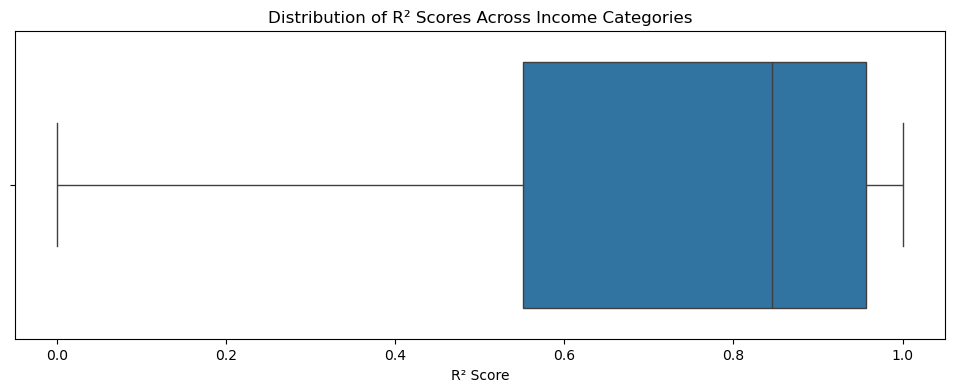

In [76]:
plt.figure(figsize=(12, 4))
r2_melt = pred_2025_income.melt(value_vars=r2_cols, var_name="Income Category", value_name="R²")

sns.boxplot(data=r2_melt, x="R²")
plt.title("Distribution of R² Scores Across Income Categories")
plt.xlabel("R² Score")
plt.show()


Plotting example county: becker


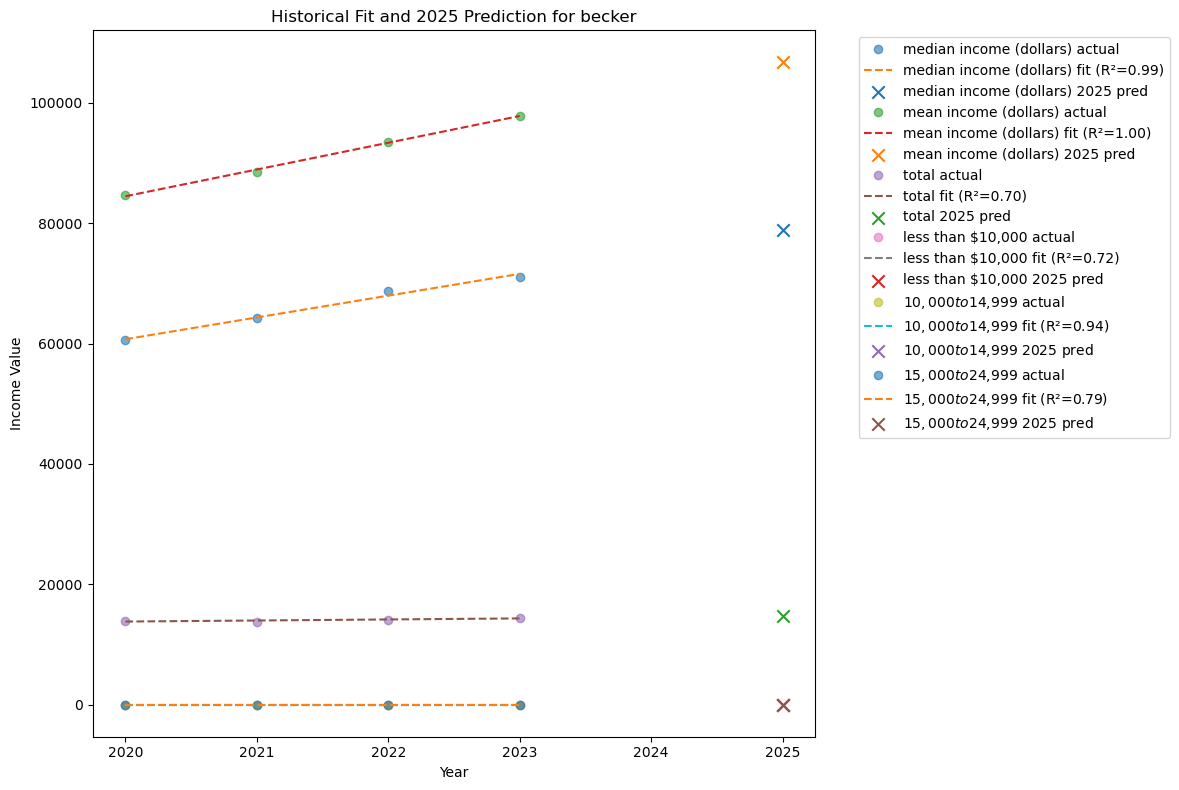

In [77]:
#use to review prediction outputs

example_county = pred_2025_income["county"].iloc[2]  
print("Plotting example county:", example_county)

g = df[df["county"] == example_county].sort_values("year")

plt.figure(figsize=(12, 8))

 # plot first 6 income columns for readability
for col in income_cols[:6]: 
    X = g["year"].values.reshape(-1,1)
    y = g[col].values

    model = LinearRegression().fit(X, y)

    y_pred_line = model.predict(X)
    y_pred_2025 = model.predict([[2025]])[0]

    plt.plot(g["year"], y, "o", alpha=0.6, label=f"{col} actual")
    plt.plot(g["year"], y_pred_line, "--", label=f"{col} fit (R²={r2_score(y, y_pred_line):.2f})")
    plt.scatter(2025, y_pred_2025, marker="x", s=80, label=f"{col} 2025 pred")

plt.title(f"Historical Fit and 2025 Prediction for {example_county}")
plt.xlabel("Year")
plt.ylabel("Income Value")
plt.legend(bbox_to_anchor=(1.05,1), loc="upper left")
plt.tight_layout()
plt.show()
